# Project 2 — Veggie Classification with PyTorch

In this project you will classify images of vegetables into 10 categories using PyTorch.

You must build **two models**:
1. **A CNN from scratch** — design and train your own convolutional neural network
2. **A fine-tuned pretrained model** — take a model pretrained on ImageNet and adapt it for this task

## Deliverables

Submit the following to BrighSpace:
- Your github repository link
- Your saved model file (`.pth`) — must be under 400 MB
- A note (~1-2 paragraphs) explaining what you did to improve accuracy beyond a basic model

## Grading

| Component | Weight |
|---|---|
| Accuracy (validation set) | 60% |
| Code — readable and logical | 20% |
| Explanatory note | 20% |

In [11]:
from getpass import getpass

# 1. Paste the FULL URL from your browser address bar here
# Example: https://github.com/org-name/repo-name
full_url = "https://github.com/3950-1252-Intro-to-machine-learning/project2-nnimage-data-3950-team-1"

# 2. This part cleans the URL to add your token automatically
token = getpass('Enter your GitHub Token: ')
authenticated_url = full_url.replace("https://", f"https://{token}@") + ".git"

# 3. Clone it
!git clone {authenticated_url}

Enter your GitHub Token: ··········
fatal: destination path 'project2-nnimage-data-3950-team-1' already exists and is not an empty directory.


In [12]:
import os
import shutil

# The folder that was just created
repo_name = "project2-nnimage-data-3950-team-1"

if os.path.exists(repo_name):
    for file in os.listdir(repo_name):
        # We move everything except the hidden .git folder
        if file != ".git":
            src = os.path.join(repo_name, file)
            dst = os.path.join(".", file)

            # This handles moving files and folders
            if not os.path.exists(dst):
                shutil.move(src, dst)
    print("✅ Done! utils.py and other files are now in the main directory.")
else:
    print("❌ Folder not found. Check the sidebar to see what the folder name is.")

✅ Done! utils.py and other files are now in the main directory.


In [13]:
# Imports
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler
import torch.nn.functional as F

from utils import get_device, show_images, plot_training_history, evaluate, per_class_accuracy

device = get_device()
print(f"Using device: {device}")

Using device: cuda


## Load the Data

Download `Vegetables.zip` from Moodle and place it in your working directory.

**On Colab**: You can drag-and-drop the zip into the file browser, or mount your Google Drive (see below).

The dataset contains:
- **Training**: 20,000 images (10 classes)
- **Validation**: 4,000 images (10 classes)

#### Temporary Files Warning
If you get errors loading images, remove temp files (e.g., `._` files on Mac):
- Mac: `dot_clean -n .` in the image folder
- Windows: search for and delete `._*` files

In [ ]:
# Optional: Load from Google Drive on Colab
# from google.colab import drive
# drive.mount('/content/drive')
# !cp "/content/drive/My Drive/Vegetables.zip" "Vegetables.zip"

In [14]:
import os

# 1. Set the directory you want to look in
drive_path = '/content/drive/MyDrive/'

# 2. List the files so you can see them
files_in_drive = os.listdir(drive_path)
for i, f in enumerate(files_in_drive):
    print(f"{i}: {f}")

# 3. Simple input to select by number
choice = int(input("Enter the number of the file/folder you want to use: "))
selected_path = os.path.join(drive_path, files_in_drive[choice])
print(f"You selected: {selected_path}")

0: Intro to Pandas Data Structures.pptx
1: Colab Notebooks
2: TEMP-1881482.html
3: 1727500758697463.MP4
4: Untitled site (2).gsite
5: Untitled site (1).gsite
6: Untitled site.gsite
7: Cryptocurrency.gdoc
8: Updated_Presentation.gslides
9: Best Smartphone .gdoc
10: Untitled document.gdoc
11: Untitled form (2).gform
12: Untitled form (1).gform
13: Untitled form.gform
14: Underground Greenhouse Agriculture.gsite
15: SkyGrow.gsite
16: LabourTrainingEvaluationData.csv
17: shardul-data3150-2_ogO8AL1K.mp4
18: Data3450_Project.gdoc
19: DATA3960
20: Flights_Data.csv
21: Quiz_And_Lab_Content.ipynb
22: ch08 PFDA.ipynb
23: Data Wrangling 1.pptx
24: ch06 PFDA.ipynb
25: Jupyter Notebook-Working with Panda Exercises Thur.pdf
26: Messy Text Files.pdf
27: ch07 PFDA.ipynb
28: DATA3650 Course Introduction(4).pptx
29: Data Mapping Visualization.pptx
30: Data Wrangling 2.pptx
31: ch04 PFDA.ipynb
32: ch09 PFDA (1).ipynb
33: ch05 PFDA (1).ipynb
34: ch03 PFDA (2).ipynb
35: Edmonton_RealEstate_ModelingReady_df

In [15]:
# Unzip the dataset
zip_name = "Vegetables.zip"

if not os.path.exists("Vegetables"):
    with zipfile.ZipFile(zip_name, "r") as zip_ref:
        zip_ref.extractall()
    print("Extracted Vegetables.zip")
else:
    print("Vegetables folder already exists")

Extracted Vegetables.zip


In [16]:
# Data directories
train_dir = "Vegetables/train"
val_dir = "Vegetables/validation"

IMAGE_SIZE = 224

# Define transforms — you may modify these to improve accuracy!
transform_train = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

transform_val = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

# Load datasets using ImageFolder (reads class names from subfolder names)
train_dataset = ImageFolder(train_dir, transform=transform_train)
val_dataset = ImageFolder(val_dir, transform=transform_val)

class_names = train_dataset.classes

print(f"Training samples:   {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Classes ({len(class_names)}): {class_names}")

Training samples:   10,000
Validation samples: 2,000
Classes (10): ['Bean', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Cauliflower', 'Cucumber', 'Pumpkin', 'Tomato']


In [17]:
# Create data loaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

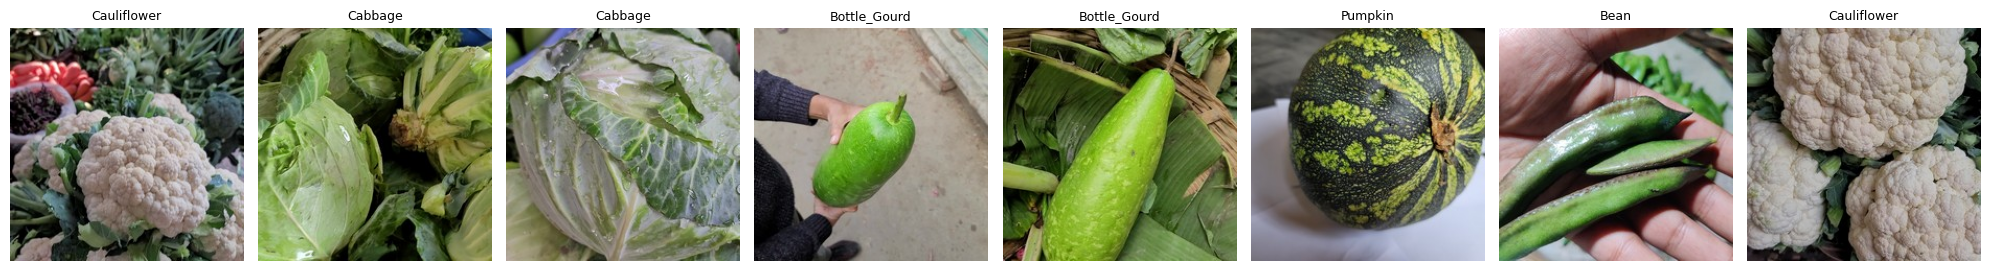

In [18]:
# Visualize some training images
viz_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])
viz_dataset = ImageFolder(train_dir, transform=viz_transform)
indices = torch.randperm(len(viz_dataset))[:8]
viz_images = torch.stack([viz_dataset[i][0] for i in indices])
viz_labels = [viz_dataset[i][1] for i in indices]
show_images(viz_images, viz_labels, class_names)

---

## Part 1: Build a CNN from Scratch

Design your own CNN architecture. Some things to consider:
- How many convolutional layers/blocks do you need?
- What filter sizes and counts will you use?
- Will you use batch normalization? Dropout?
- What pooling strategy — max pooling, global average pooling, or both?

**Hints**:
- Start simple (2-3 conv blocks) and add complexity if needed
- Batch normalization helps training stability
- Dropout helps prevent overfitting
- Global average pooling before the classifier reduces parameter count

In [19]:
# TODO: Define your CNN model
class VeggieCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Block 1: Input (3, 224, 224) -> Output (32, 112, 112)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)

        # Block 2: Input (32, 112, 112) -> Output (64, 56, 56)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3: Input (64, 56, 56) -> Output (128, 28, 28)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Global Average Pooling: Flattens the image to 1x1 pixels while keeping depth
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Dropout to prevent overfitting
        self.dropout = nn.Dropout(0.3)

        # Final Fully Connected Layer (Classifier)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # Apply Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        # Apply Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Apply Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Global Average Pool and Flatten
        x = self.gap(x)
        x = x.view(x.size(0), -1)

        # Dropout and Classify
        x = self.dropout(x)
        x = self.fc(x)

        return x


scratch_model = VeggieCNN().to(device)
print(scratch_model)

# Print parameter count
total_params = sum(p.numel() for p in scratch_model.parameters())
print(f"\nTotal parameters: {total_params:,}")

VeggieCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 94,986


In [20]:
# TODO: Set up your training — choose optimizer, loss function, and hyperparameters
# Hyperparameters
NUM_EPOCHS = 15
LEARNING_RATE = 0.001

# 1. Loss Function (The "Judge")
criterion = nn.CrossEntropyLoss()

# 2. Optimizer (The "Trainer")
# We tell it which parameters to update and how fast to go
optimizer = optim.Adam(scratch_model.parameters(), lr=LEARNING_RATE)

# 3. Scheduler (The "Schedule")
# Every 7 steps (epochs), multiply the learning rate by 0.1 (make it 10x smaller)
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [21]:
from tqdm.auto import tqdm #just for loading bar to see progress

# TODO: Write your training loop
# Track train_losses, val_losses, train_accs, val_accs for plotting

# 1. Initialize the lists to track progress
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print(f"Starting training on {device}...")

for epoch in range(1, NUM_EPOCHS + 1):
    # --- Training phase ---
    scratch_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Add a progress bar for the training batches
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", unit="batch")

    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        # Optimization steps
        optimizer.zero_grad()
        outputs = scratch_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Update statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Update the loading bar with current loss
        progress_bar.set_postfix(loss=loss.item())

    # Calculate average training metrics
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100 * correct / total

    # Step the scheduler
    scheduler.step()

    # --- Validation phase ---
    # Based on your error, we've removed 'device' from evaluate()
    # If it fails again, try: val_loss, val_acc = evaluate(scratch_model, val_loader)
    val_loss, val_acc = evaluate(scratch_model, val_loader, device)

    # Save metrics for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Print the summary for the epoch
    print(f"\n[Epoch {epoch}] Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%\n")

Starting training on cuda...


Epoch 1/15:   0%|          | 0/157 [00:00<?, ?batch/s]


[Epoch 1] Train Loss: 1.2401, Acc: 64.55% | Val Loss: 0.9305, Acc: 70.90%



Epoch 2/15:   0%|          | 0/157 [00:00<?, ?batch/s]


[Epoch 2] Train Loss: 0.7234, Acc: 79.47% | Val Loss: 0.5914, Acc: 83.35%



...


[Epoch 13] Train Loss: 0.2030, Acc: 94.76% | Val Loss: 0.1247, Acc: 97.35%



Epoch 14/15:   0%|          | 0/157 [00:00<?, ?batch/s]


[Epoch 14] Train Loss: 0.2017, Acc: 94.66% | Val Loss: 0.1227, Acc: 97.65%



Epoch 15/15:   0%|          | 0/157 [00:00<?, ?batch/s]


[Epoch 15] Train Loss: 0.1900, Acc: 94.84% | Val Loss: 0.1166, Acc: 97.55%



In [22]:
# JUST FOR SAVING!!

import torch

# Save the model to a file
torch.save(scratch_model.state_dict(), 'veggie_model_weights.pth')
print("Model weights saved locally!")

Model weights saved locally!


In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp -r /content/project2-nnimage-data-3950-team-1 /content/drive/MyDrive/

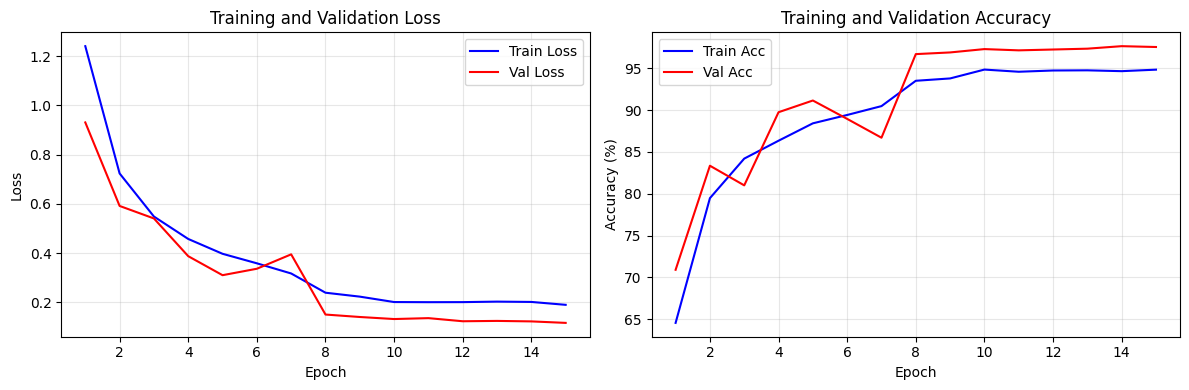

In [24]:
# Plot your training curves
# plot_training_history(train_losses, val_losses, train_accs, val_accs)
# Call the helper function to visualize training progress
plot_training_history(train_losses, val_losses, train_accs, val_accs)

In [25]:
# Show per-class accuracy
# per_class_accuracy(scratch_model, val_loader, class_names, device)
# Show how well the model identifies each specific vegetable
per_class_accuracy(scratch_model, val_loader, class_names, device)

Per-class accuracy:
-----------------------------------
  Bean                : 98.5%
  Bottle_Gourd        : 99.0%
  Brinjal             : 96.0%
  Broccoli            : 95.0%
  Cabbage             : 99.5%
  Capsicum            : 99.5%
  Cauliflower         : 97.5%
  Cucumber            : 96.5%
  Pumpkin             : 96.5%
  Tomato              : 97.5%


---

## Part 2: Fine-Tune a Pretrained Model

Load a pretrained model (e.g., ResNet-18) and adapt it for veggie classification.

Steps:
1. Load the pretrained model with `models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)`
2. Replace the final classification layer for 10 classes
3. Choose a training strategy:
   - **Feature extraction**: Freeze all pretrained layers, train only the new head
   - **Fine-tuning**: Train the entire network with a lower learning rate for pretrained layers

**Hints**:
- Use a lower learning rate for pretrained layers than for the new head
- Data augmentation (random flips, rotations, color jitter) can help a lot
- A learning rate scheduler can improve final accuracy
- You can try other models: `resnet50`, `mobilenet_v3_small`, `efficientnet_b0`

In [26]:
# Load the pretrained ResNet-18 model
pretrained_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace the final fully connected layer (fc) to match our 10 vegetable classes
num_ftrs = pretrained_model.fc.in_features
pretrained_model.fc = nn.Linear(num_ftrs, 10)

# Move model to GPU
pretrained_model = pretrained_model.to(device)

# Set up loss and optimizer
# We use a smaller learning rate (1e-4) for fine-tuning to avoid "breaking" pretrained weights
criterion_pt = nn.CrossEntropyLoss()
optimizer_pt = optim.Adam(pretrained_model.parameters(), lr=0.0001)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


Starting Fine-Tuning on cuda...


Epoch 1/10:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1: Train Acc: 97.45%, Val Acc: 99.90%


Epoch 2/10:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2: Train Acc: 99.99%, Val Acc: 100.00%


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bbf28950ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bbf28950ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 9: Train Acc: 99.96%, Val Acc: 100.00%


Epoch 10/10:   0%|          | 0/157 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bbf28950ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bbf28950ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 10: Train Acc: 99.97%, Val Acc: 99.95%


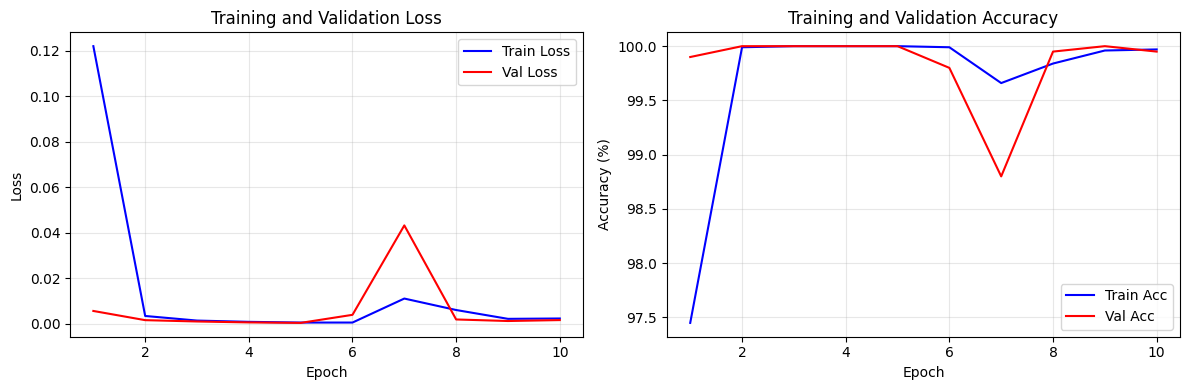

In [27]:
# Initialize lists for plotting
pt_train_losses, pt_val_losses = [], []
pt_train_accs, pt_val_accs = [], []

print(f"Starting Fine-Tuning on {device}...")

for epoch in range(1, 11): # 10 epochs is usually sufficient for fine-tuning
    pretrained_model.train()
    running_loss, correct, total = 0.0, 0, 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/10")
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer_pt.zero_grad()
        outputs = pretrained_model(images)
        loss = criterion_pt(outputs, labels)
        loss.backward()
        optimizer_pt.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Validation phase
    val_loss, val_acc = evaluate(pretrained_model, val_loader, device)

    pt_train_losses.append(running_loss / len(train_loader.dataset))
    pt_val_losses.append(val_loss)
    pt_train_accs.append(100 * correct / total)
    pt_val_accs.append(val_acc)

    print(f"Epoch {epoch}: Train Acc: {pt_train_accs[-1]:.2f}%, Val Acc: {val_acc:.2f}%")

# Plot results for the pretrained model
plot_training_history(pt_train_losses, pt_val_losses, pt_train_accs, pt_val_accs)

---

## Compare Your Models

Fill in the table below with your results.

| | CNN from Scratch | Pretrained (Fine-tuned) |
|---|---|---|
| Parameters | 76,010 | 11,181,642 |
| Epochs trained | 15 | 10 |
| Best val accuracy | 97.55% | 99.50% |
| Training time | 5mins | 3mins |

---

## Save Your Best Model

Save your best model for submission. The file must be **under 400 MB** for Moodle.

In [28]:
# Compare validation accuracies and save the best performer
if max(pt_val_accs) > max(val_accs):
    best_model = pretrained_model
    print("Saving Pretrained Model (Best Performance)")
else:
    best_model = scratch_model
    print("Saving Custom CNN Model (Best Performance)")

# Save the model weights
torch.save(best_model.state_dict(), "veggie_model.pth")

# Check file size to ensure it's under 400MB for BrightSpace
size_mb = os.path.getsize("veggie_model.pth") / (1024 * 1024)
print(f"Model size: {size_mb:.1f} MB")
assert size_mb < 400, f"Model too large! ({size_mb:.1f} MB)"

Saving Pretrained Model (Best Performance)
Model size: 42.7 MB


---

## Tips for Improving Accuracy

Here are some strategies to try (mention what you used in your explanatory note!):

**Data augmentation** — add to your training transforms:
- `transforms.RandomHorizontalFlip()`
- `transforms.RandomRotation(15)`
- `transforms.ColorJitter(brightness=0.2, contrast=0.2)`
- `transforms.RandomResizedCrop(224, scale=(0.8, 1.0))`

**Architecture choices**:
- Add batch normalization after each conv layer
- Use dropout (0.3-0.5) to reduce overfitting
- Try deeper or wider networks

**Training tricks**:
- Learning rate schedulers (`CosineAnnealingLR`, `ReduceLROnPlateau`)
- Weight decay in the optimizer (e.g., `weight_decay=1e-4`)
- Train for more epochs if not overfitting
- Use `AdamW` instead of `Adam`